# 01. 데이터 개요 및 품질 분석

MindTune 프로젝트의 핵심 데이터셋인 `Music_recommendation.csv`의 기본 구조, 품질, 분포를 탐색합니다.

**분석 목표**:
- 데이터 형태 및 컬럼 구조 파악
- 결측값, 중복 데이터 확인
- 주요 수치형/범주형 변수 분포 확인
- 이상치 탐지

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
plt.rcParams['font.size'] = 11
plt.rcParams['figure.figsize'] = (12, 6)
sns.set_style('whitegrid')

# 한글 폰트 설정 (환경에 따라 조정)
plt.rcParams['axes.unicode_minus'] = False
# try:
#     plt.rcParams['font.family'] = 'NanumGothic'
# except:
#     pass  # 폰트 없으면 기본 폰트 사용

df = pd.read_csv('../data/Music_recommendation.csv')
print(f"데이터셋 크기: {df.shape[0]:,}행 × {df.shape[1]}열")
df.head(3)

데이터셋 크기: 32,833행 × 25열


,track_id,track_name,track_artist,track_popularity,track_album_id,track_album_name,track_album_release_date,playlist_name,playlist_id,playlist_genre,...,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms,Mental_Health_Label,instrument
0,697MjF1454XKvZmTuqkWmD,I Miss You,Jeriqo,45,2vJ6FDg6ZMS56U8Wbiw2Oz,I Miss You,2019-02-05,Pop Hits 2000-2019,6mtYuOxzl58vSGnEDtZ9uB,edm,...,1,0.0432,0.00491,0.000013,0.0816,0.415,174.026,216347,Normal/Unclassified,Unknown
1,3x2bXiU0o4WbsPkawXlfDA,Who Are You,The Who,17,6LRJF97hgXHj8uMLHyCDbh,Who Are You (Remastered),1978-08-18,House Of The Rising Sun,1bMYfBHYBCRHY5LGkjlpSy,rock,...,1,0.0511,0.26500,0.003130,0.1060,0.489,156.371,378707,Normal/Unclassified,Guitar/Drums
2,0jEaPBjFAWjQTMVouRwaHi,Happy,The Beef Seeds,30,4IQn9XpweytNX2cUe2NBUH,Keepin' it Beefy,2015-01-19,Bluegrass Covers,37i9dQZF1DX56crgoe4TG3,r&b,...,1,0.1600,0.66500,0.000000,0.1270,0.932,86.529,218044,Bipolar (Mania),Unknown


## 1.1 컬럼 구조 및 데이터 타입

In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 32833 entries, 0 to 32832
Data columns (total 25 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   track_id                  32833 non-null  str    
 1   track_name                32828 non-null  str    
 2   track_artist              32828 non-null  str    
 3   track_popularity          32833 non-null  int64  
 4   track_album_id            32833 non-null  str    
 5   track_album_name          32828 non-null  str    
 6   track_album_release_date  32833 non-null  str    
 7   playlist_name             32833 non-null  str    
 8   playlist_id               32833 non-null  str    
 9   playlist_genre            32833 non-null  str    
 10  playlist_subgenre         32833 non-null  str    
 11  danceability              32833 non-null  float64
 12  energy                    32833 non-null  float64
 13  key                       32833 non-null  int64  
 14  loudness         

## 1.2 수치형 피처 요약 통계

In [3]:
df.describe().round(3)

,track_popularity,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms
count,32833.000,32833.000,32833.000,32833.000,32833.000,32833.000,32833.000,32833.000,32833.000,32833.000,32833.000,32833.000,32833.000
mean,42.477,0.655,0.699,5.374,-6.719,0.566,0.107,0.175,0.085,0.190,0.511,120.881,225799.812
std,24.984,0.145,0.181,3.612,2.988,0.496,0.101,0.220,0.224,0.154,0.233,26.904,59834.006
min,0.000,0.000,0.000,0.000,-46.448,0.000,0.000,0.000,0.000,0.000,0.000,0.000,4000.000
25%,24.000,0.563,0.581,2.000,-8.171,0.000,0.041,0.015,0.000,0.093,0.331,99.960,187819.000
50%,45.000,0.672,0.721,6.000,-6.166,1.000,0.062,0.080,0.000,0.127,0.512,121.984,216000.000
75%,62.000,0.761,0.840,9.000,-4.645,1.000,0.132,0.255,0.005,0.248,0.693,133.918,253585.000
max,100.000,0.983,1.000,11.000,1.275,1.000,0.918,0.994,0.994,0.996,0.991,239.440,517810.000


## 1.3 결측값 분석

In [4]:
# 결측값이 있는 컬럼만 표시
missing = df.isnull().sum()
missing_cols = missing[missing > 0]
print("=== 결측값이 있는 컬럼 ===")
print(missing_cols)
print(f"\n전체 결측률: {df.isnull().sum().sum() / df.size * 100:.4f}%")

# 결측 행 직접 확인
print("\n=== 결측값 포함 행 ===")
df[df.isnull().any(axis=1)]

=== 결측값이 있는 컬럼 ===
track_name          5
track_artist        5
track_album_name    5
dtype: int64

전체 결측률: 0.0018%

=== 결측값 포함 행 ===


,track_id,track_name,track_artist,track_popularity,track_album_id,track_album_name,track_album_release_date,playlist_name,playlist_id,playlist_genre,...,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms,Mental_Health_Label,instrument
4195,3VKFip3OdAvv4OfNTgFWeQ,NaN,NaN,0,717UG2du6utFe7CdmpuUe3,NaN,2012-01-05,Reggaeton viejito🔥,0si5tw70PIgPkY1Eva6V8f,latin,...,0,0.0366,0.0606,0.00653,0.1030,0.726,97.017,252773,Bipolar (Mania),Unknown
4888,69gRFGOWY9OMpFJgFol1u0,NaN,NaN,0,717UG2du6utFe7CdmpuUe3,NaN,2012-01-05,HIP&HOP,5DyJsJZOpMJh34WvUrQzMV,rap,...,1,0.1760,0.0410,0.00000,0.1160,0.649,95.999,282707,Normal/Unclassified,Unknown
14917,5cjecvX0CmC9gK0Laf5EMQ,NaN,NaN,0,3luHJEPw434tvNbme3SP8M,NaN,2017-12-01,GANGSTA Rap,5GA8GDo7RQC3JEanT81B3g,rap,...,0,0.3190,0.0534,0.00000,0.5530,0.191,146.153,202235,Anxiety,Unknown
29000,5TTzhRSWQS4Yu8xTgAuq6D,NaN,NaN,0,3luHJEPw434tvNbme3SP8M,NaN,2017-12-01,GANGSTA Rap,5GA8GDo7RQC3JEanT81B3g,rap,...,0,0.3070,0.0963,0.00000,0.0888,0.505,86.839,206465,Normal/Unclassified,Unknown
30337,69gRFGOWY9OMpFJgFol1u0,NaN,NaN,0,717UG2du6utFe7CdmpuUe3,NaN,2012-01-05,latin hip hop,3nH8aytdqNeRbcRCg3dw9q,latin,...,1,0.1760,0.0410,0.00000,0.1160,0.649,95.999,282707,Normal/Unclassified,Unknown


## 1.4 중복 분석

In [5]:
# track_id 기준 중복
dup_id = df['track_id'].duplicated().sum()
print(f"track_id 기준 중복: {dup_id}건")

# track_name + track_artist 기준 중복 (동일 곡이 여러 플레이리스트에 포함된 경우)
dup_name_artist = df.duplicated(subset=['track_name', 'track_artist']).sum()
print(f"track_name + track_artist 기준 중복: {dup_name_artist}건")

# 중복 예시 확인
if dup_name_artist > 0:
    dup_examples = df[df.duplicated(subset=['track_name', 'track_artist'], keep=False)]
    print(f"\n중복 곡 수: {dup_examples['track_name'].nunique()}개 고유 곡이 여러 번 등장")
    print("\n=== 가장 많이 등장하는 곡 Top 10 ===")
    top_dups = dup_examples.groupby(['track_name', 'track_artist']).size().sort_values(ascending=False).head(10)
    print(top_dups)

track_id 기준 중복: 4477건


track_name + track_artist 기준 중복: 6603건

중복 곡 수: 3943개 고유 곡이 여러 번 등장

=== 가장 많이 등장하는 곡 Top 10 ===
track_name                                     track_artist  
Señorita                                       Shawn Mendes      13
One Dance                                      Drake             12
Dance Monkey                                   Tones and I       12
I Don't Care (with Justin Bieber)              Ed Sheeran        12
Sweet Home Alabama                             Lynyrd Skynyrd    11
Sunflower - Spider-Man: Into the Spider-Verse  Post Malone       11
ROXANNE                                        Arizona Zervas    11
Livin' On A Prayer                             Bon Jovi          11
Circles                                        Post Malone       10
Eye of the Tiger                               Survivor          10
dtype: int64


## 1.5 곡 길이(duration_ms) 분포 및 이상치

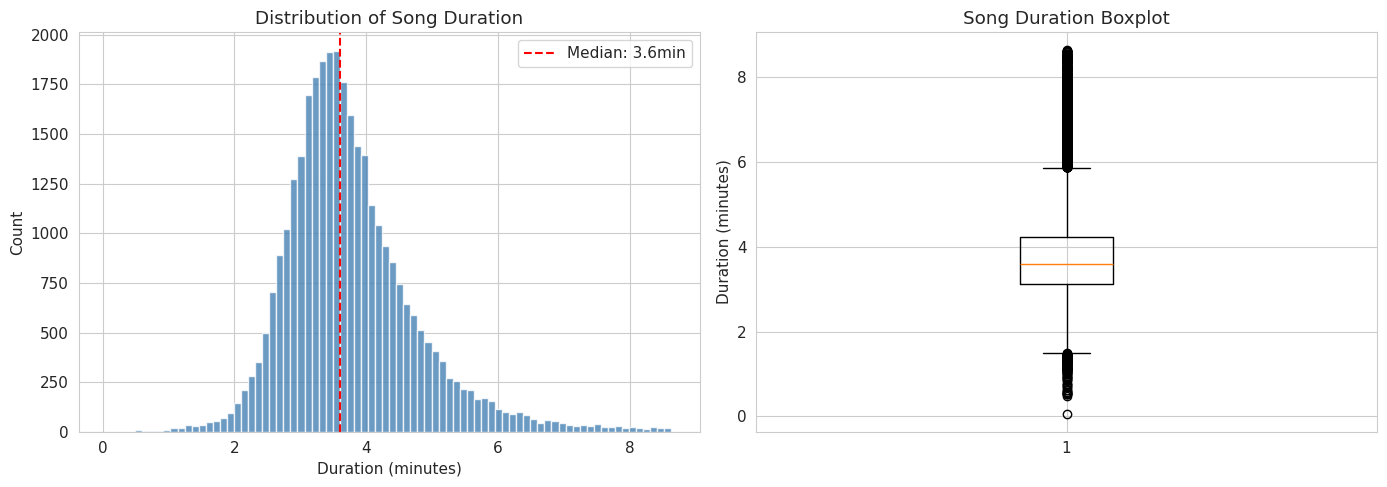

최단 곡: 0.07분 (4초)
최장 곡: 8.63분
1분 미만: 25곡
10분 초과: 0곡


In [6]:
df['duration_min'] = df['duration_ms'] / 60000

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 히스토그램
axes[0].hist(df['duration_min'], bins=80, color='steelblue', edgecolor='white', alpha=0.8)
axes[0].set_xlabel('Duration (minutes)')
axes[0].set_ylabel('Count')
axes[0].set_title('Distribution of Song Duration')
axes[0].axvline(df['duration_min'].median(), color='red', linestyle='--', label=f"Median: {df['duration_min'].median():.1f}min")
axes[0].legend()

# 박스플롯
axes[1].boxplot(df['duration_min'], vert=True)
axes[1].set_ylabel('Duration (minutes)')
axes[1].set_title('Song Duration Boxplot')

plt.tight_layout()
plt.show()

# 이상치 확인
print(f"최단 곡: {df['duration_min'].min():.2f}분 ({df['duration_ms'].min()/1000:.0f}초)")
print(f"최장 곡: {df['duration_min'].max():.2f}분")
print(f"1분 미만: {(df['duration_min'] < 1).sum()}곡")
print(f"10분 초과: {(df['duration_min'] > 10).sum()}곡")

## 1.6 인기도(track_popularity) 분포

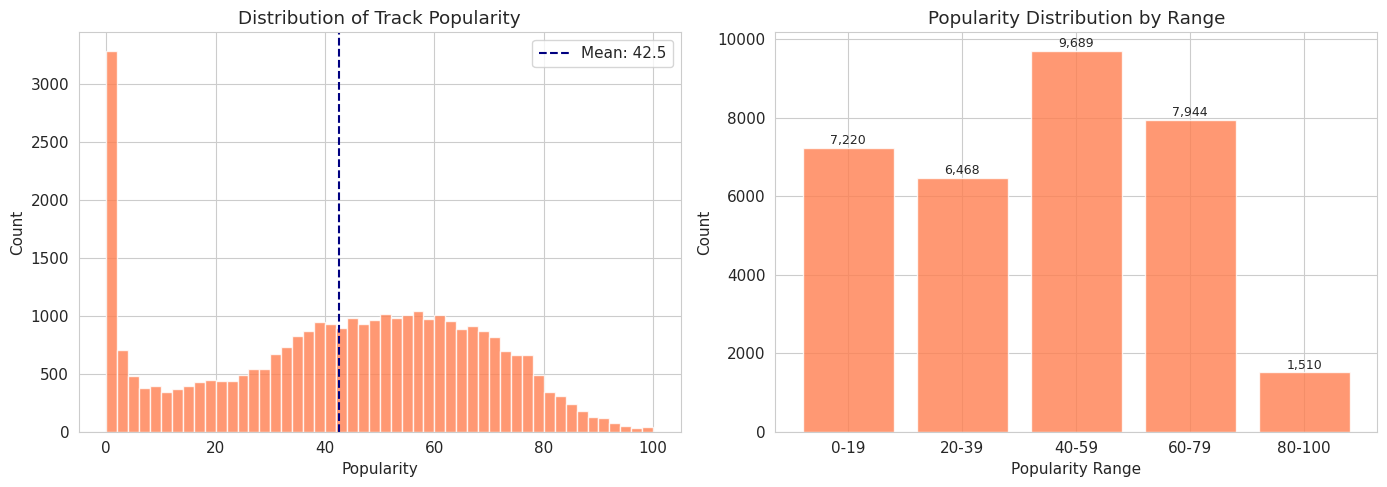

인기도 0인 곡: 2703곡
인기도 80+ 곡: 1512곡


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 인기도 분포
axes[0].hist(df['track_popularity'], bins=50, color='coral', edgecolor='white', alpha=0.8)
axes[0].set_xlabel('Popularity')
axes[0].set_ylabel('Count')
axes[0].set_title('Distribution of Track Popularity')
axes[0].axvline(df['track_popularity'].mean(), color='navy', linestyle='--', label=f"Mean: {df['track_popularity'].mean():.1f}")
axes[0].legend()

# 인기도 구간별 비율
bins = [0, 20, 40, 60, 80, 100]
labels = ['0-19', '20-39', '40-59', '60-79', '80-100']
df['popularity_bin'] = pd.cut(df['track_popularity'], bins=bins, labels=labels, right=False)
pop_dist = df['popularity_bin'].value_counts().sort_index()
axes[1].bar(pop_dist.index, pop_dist.values, color='coral', edgecolor='white', alpha=0.8)
axes[1].set_xlabel('Popularity Range')
axes[1].set_ylabel('Count')
axes[1].set_title('Popularity Distribution by Range')
for i, v in enumerate(pop_dist.values):
    axes[1].text(i, v + 100, f'{v:,}', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

print(f"인기도 0인 곡: {(df['track_popularity'] == 0).sum()}곡")
print(f"인기도 80+ 곡: {(df['track_popularity'] >= 80).sum()}곡")

## 1.7 앨범 릴리스 연도 분포

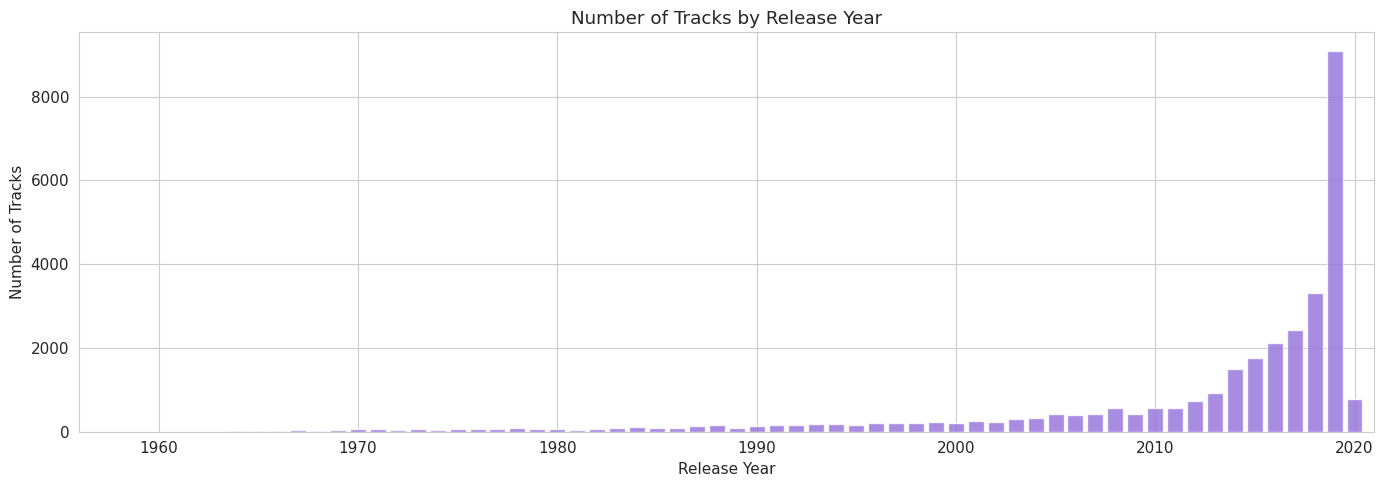

가장 오래된 곡: 1957년
가장 최근 곡: 2020년
2010년 이후 곡 비율: 72.4%
릴리스 날짜 파싱 실패: 1886건


In [8]:
# 릴리스 날짜에서 연도 추출 (다양한 형식 대응)
df['release_year'] = pd.to_datetime(df['track_album_release_date'], errors='coerce').dt.year

year_counts = df['release_year'].dropna().astype(int).value_counts().sort_index()

fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(year_counts.index, year_counts.values, color='mediumpurple', edgecolor='white', alpha=0.8)
ax.set_xlabel('Release Year')
ax.set_ylabel('Number of Tracks')
ax.set_title('Number of Tracks by Release Year')
ax.set_xlim(year_counts.index.min() - 1, year_counts.index.max() + 1)
plt.tight_layout()
plt.show()

print(f"가장 오래된 곡: {int(year_counts.index.min())}년")
print(f"가장 최근 곡: {int(year_counts.index.max())}년")
print(f"2010년 이후 곡 비율: {(df['release_year'] >= 2010).sum() / len(df) * 100:.1f}%")
print(f"릴리스 날짜 파싱 실패: {df['release_year'].isna().sum()}건")

## 1.8 instrument 컬럼 분포

instrument 고유값 수: 3

=== instrument 분포 ===
instrument
Unknown         27627
Guitar/Drums     5015
Synth             191
Name: count, dtype: int64


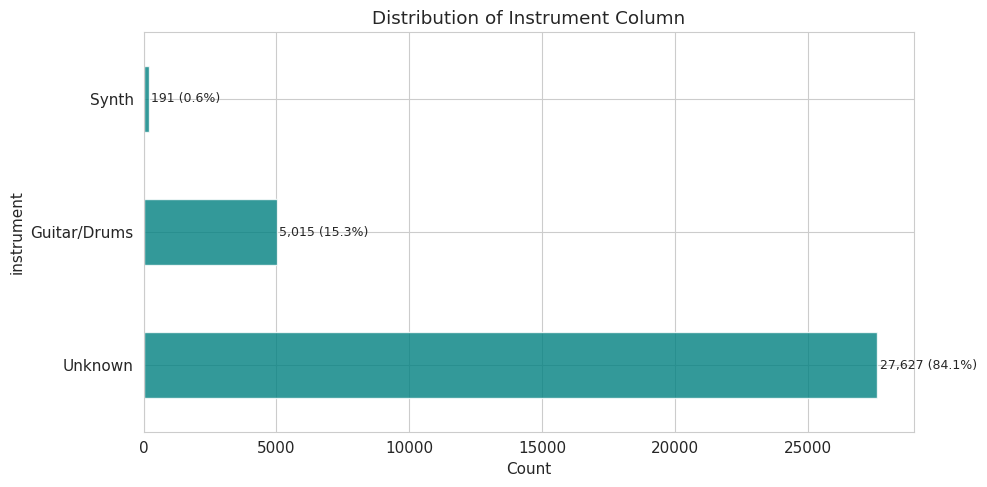

In [9]:
inst_counts = df['instrument'].value_counts()
print(f"instrument 고유값 수: {df['instrument'].nunique()}")
print(f"\n=== instrument 분포 ===")
print(inst_counts)

fig, ax = plt.subplots(figsize=(10, 5))
inst_counts.plot(kind='barh', ax=ax, color='teal', edgecolor='white', alpha=0.8)
ax.set_xlabel('Count')
ax.set_title('Distribution of Instrument Column')
for i, v in enumerate(inst_counts.values):
    ax.text(v + 100, i, f'{v:,} ({v/len(df)*100:.1f}%)', va='center', fontsize=9)
plt.tight_layout()
plt.show()

## 1.9 요약

**데이터 품질 결론**:
- **결측값**: 극소수 (5건, track_name/track_artist/track_album_name) → 제거 가능
- **중복**: track_id 기준 및 곡명+아티스트 기준 중복 여부 확인 필요 (동일 곡이 여러 플레이리스트에 포함)
- **이상치**: duration_ms에서 극단적으로 짧거나 긴 곡 존재 가능 → 전처리 시 필터링 고려
- **instrument 컬럼**: "Unknown"이 대다수일 경우 추천에 직접 활용하기 어려움
- **시간 분포**: 데이터셋의 곡이 어떤 시대에 집중되어 있는지 확인됨